# Extracción de datos climáticos mediante API

Este notebook presenta el proceso utilizado para obtener las condiciones climáticas
horarias de los cinco boroughs de Nueva York a partir de la API de datos históricos
de Open-Meteo. La información se utiliza para incorporar la dimensión climática en
la definición de las ventanas de riesgo del proyecto.

**Dependencias:** `requests`, `pandas`, `matplotlib` y `pyarrow` (o `fastparquet`)
para guardar los datos en formato Parquet.

## 1. Importación de librerías

Se utilizan `Requests` para realizar las consultas a la API, `time` para espaciar
las llamadas, `Pandas` para estructurar y transformar los datos recibidos y
`Matplotlib` para visualizar la precipitación.

In [1]:
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt

## 2. Obtención de la fuente

La fuente utilizada es la API de datos históricos de Open-Meteo, un servicio gratuito
que no requiere registro ni clave de acceso. Cada petición HTTP devuelve un archivo
JSON con series horarias para las coordenadas solicitadas.

Los datos provienen de modelos de reanálisis (como ERA5), por lo que cada valor
corresponde a la celda de la cuadrícula del modelo más cercana al punto consultado
y no a una medición directa de una estación meteorológica.

### Parámetros de la consulta

Se consulta un punto representativo por cada borough:

| Borough | Latitud | Longitud |
|---|---|---|
| Manhattan | 40.7831 | -73.9712 |
| Brooklyn | 40.6782 | -73.9442 |
| Queens | 40.7282 | -73.7949 |
| Bronx | 40.8448 | -73.8648 |
| Staten Island | 40.5795 | -74.1502 |

Para cada punto se solicitan las variables horarias de temperatura, precipitación,
nevadas, código de condición climática, visibilidad y velocidad del viento, entre el
1 de enero de 2013 y el 20 de septiembre de 2026. La zona horaria `America/New_York`
hace que la API entregue la hora local y no la hora UTC, de modo que coincida con la
hora de los choques y las denuncias.

In [2]:
URL = "https://archive-api.open-meteo.com/v1/archive"

# Punto representativo de cada borough: (latitud, longitud)
boroughs = {
    "Manhattan": (40.7831, -73.9712),
    "Brooklyn": (40.6782, -73.9442),
    "Queens": (40.7282, -73.7949),
    "Bronx": (40.8448, -73.8648),
    "Staten Island": (40.5795, -74.1502),
}

ANIO_INICIO, ANIO_FIN = 2013, 2026
FECHA_FIN_2026 = "2026-09-20"  # el último año se consulta solo hasta esta fecha

### Descarga de los datos

Se realiza una llamada por borough y por año (5 boroughs × 14 años = 70 llamadas).
Entre una llamada y la siguiente se espera un segundo para no saturar el servicio.
El último año (2026) se consulta únicamente hasta el 20 de septiembre.

In [3]:
partes = []

for nombre, (lat, lon) in boroughs.items():
    for anio in range(ANIO_INICIO, ANIO_FIN + 1):
        p = {
            "latitude": lat,
            "longitude": lon,
            "start_date": f"{anio}-01-01",
            "end_date": f"{anio}-12-31" if anio < ANIO_FIN else FECHA_FIN_2026,
            # Variables horarias solicitadas a la API
            "hourly": "temperature_2m,precipitation,snowfall,weather_code,visibility,wind_speed_10m",
            # Hora local de Nueva York en lugar de UTC
            "timezone": "America/New_York",
        }
        r = requests.get(URL, params=p, timeout=60)
        r.raise_for_status()
        df = pd.DataFrame(r.json()["hourly"])
        df["borough"] = nombre
        partes.append(df)
        time.sleep(1)  # pausa entre llamadas para respetar los límites del servicio
        print(nombre, anio, "ok")

Manhattan 2013 ok
Manhattan 2014 ok
Manhattan 2015 ok
Manhattan 2016 ok
Manhattan 2017 ok
Manhattan 2018 ok
Manhattan 2019 ok
Manhattan 2020 ok
Manhattan 2021 ok
Manhattan 2022 ok
Manhattan 2023 ok
Manhattan 2024 ok
Manhattan 2025 ok
Manhattan 2026 ok
Brooklyn 2013 ok
Brooklyn 2014 ok
Brooklyn 2015 ok
Brooklyn 2016 ok
Brooklyn 2017 ok
Brooklyn 2018 ok
Brooklyn 2019 ok
Brooklyn 2020 ok
Brooklyn 2021 ok
Brooklyn 2022 ok
Brooklyn 2023 ok
Brooklyn 2024 ok
Brooklyn 2025 ok
Brooklyn 2026 ok
Queens 2013 ok
Queens 2014 ok
Queens 2015 ok
Queens 2016 ok
Queens 2017 ok
Queens 2018 ok
Queens 2019 ok
Queens 2020 ok
Queens 2021 ok
Queens 2022 ok
Queens 2023 ok
Queens 2024 ok
Queens 2025 ok
Queens 2026 ok
Bronx 2013 ok
Bronx 2014 ok
Bronx 2015 ok
Bronx 2016 ok
Bronx 2017 ok
Bronx 2018 ok
Bronx 2019 ok
Bronx 2020 ok
Bronx 2021 ok
Bronx 2022 ok
Bronx 2023 ok
Bronx 2024 ok
Bronx 2025 ok
Bronx 2026 ok
Staten Island 2013 ok
Staten Island 2014 ok
Staten Island 2015 ok
Staten Island 2016 ok
Staten Island 20

## 3. Preparación de la información

Las respuestas de todas las llamadas se concatenan en una sola tabla. A partir de la
marca de tiempo se construyen las columnas `fecha`, `hora` y `mes`, que se utilizan
como llaves para cruzar el clima con los datos de choques y denuncias.

In [4]:
clima = pd.concat(partes, ignore_index=True)

clima["time"] = pd.to_datetime(clima["time"])
clima["fecha"] = clima["time"].dt.date
clima["hora"] = clima["time"].dt.hour
clima["mes"] = clima["time"].dt.to_period("M").astype(str)

print("Filas:", len(clima))

Filas: 601320


## 4. Clasificación de la condición climática

La API entrega el estado del tiempo como un código numérico definido por la
Organización Meteorológica Mundial (WMO). Para facilitar el análisis, estos códigos
se agrupan en categorías interpretables:

| Categoría | Códigos WMO |
|---|---|
| Despejado | 0 y 1 |
| Nublado | 2 y 3 |
| Niebla | 45 y 48 |
| Lluvia | 51 a 67 y 80 a 82 |
| Nieve | 71 a 77, 85 y 86 |
| Tormenta | 95 o más |
| Otro | Cualquier otro código |

En los datos extraídos solo aparecen cuatro categorías: despejado, nublado, lluvia
y nieve. La columna `condicion` define la dimensión climática de las ventanas de riesgo.

In [5]:
def categoria(c):
    if c in (0, 1):
        return "Despejado"
    if c in (2, 3):
        return "Nublado"
    if c in (45, 48):
        return "Niebla"
    if 51 <= c <= 67 or 80 <= c <= 82:
        return "Lluvia"
    if 71 <= c <= 77 or 85 <= c <= 86:
        return "Nieve"
    if c >= 95:
        return "Tormenta"
    return "Otro"


clima["condicion"] = clima["weather_code"].apply(categoria)

## 5. Resumen de la información

Se calculan tablas y gráficos de apoyo para verificar que los datos extraídos son
coherentes y para describir el comportamiento del clima en cada borough.

### Resumen anual por borough

Para cada borough y año se calcula la temperatura media, la precipitación total, la
nieve acumulada y la velocidad media del viento.

In [6]:
clima["anio"] = clima["time"].dt.year

resumen = (
    clima.groupby(["borough", "anio"])
    .agg(temp_media_c=("temperature_2m", "mean"),
         precip_total_mm=("precipitation", "sum"),
         nieve_total_cm=("snowfall", "sum"),
         viento_medio_kmh=("wind_speed_10m", "mean"))
    .round(1)
)

print(resumen)

                    temp_media_c  precip_total_mm  nieve_total_cm  \
borough       anio                                                  
Bronx         2013          11.5            973.2            85.5   
              2014          10.8           1026.6            95.3   
              2015          11.7            970.9            87.7   
              2016          12.5            906.9            66.3   
              2017          12.1           1099.0            80.8   
...                          ...              ...             ...   
Staten Island 2022          12.8           1381.3            43.6   
              2023          13.4           1413.8            15.3   
              2024          13.4           1184.0            37.8   
              2025          12.8           1101.7            42.4   
              2026          14.2            915.9            59.7   

                    viento_medio_kmh  
borough       anio                    
Bronx         2013      

### Horas por condición climática

Se cuenta cuántas horas de cada condición se registraron en cada borough. Esta
distribución es la base para calcular tasas por hora observada. Las condiciones
adversas son minoritarias (cerca del 13 % de las horas con lluvia y del 2 % con
nieve), por lo que los conteos brutos de choques no son comparables entre condiciones.

In [7]:
horas_por_condicion = pd.crosstab(clima["borough"], clima["condicion"])

print(horas_por_condicion)

condicion      Despejado  Lluvia  Nieve  Nublado
borough                                         
Bronx              49865   16198   2254    51947
Brooklyn           49990   16084   2076    52114
Manhattan          49677   15985   2230    52372
Queens             50056   16167   2182    51859
Staten Island      49960   15979   2050    52275


### Precipitación anual

Se grafica la precipitación total anual de cada borough. El año 2026 llega solo hasta
el 20 de septiembre, por lo que su valor más bajo corresponde a un periodo incompleto
y no a una reducción de la lluvia.

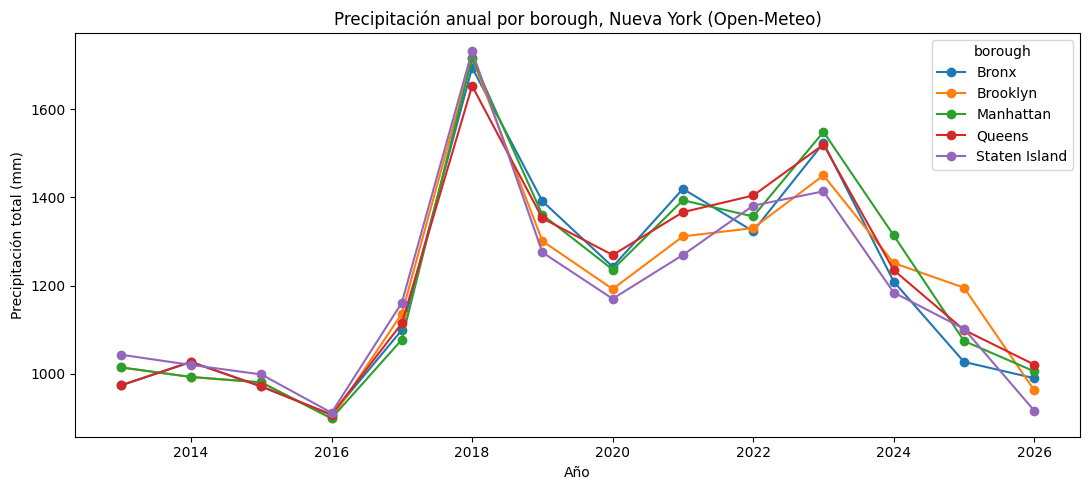

In [8]:
pivot = resumen["precip_total_mm"].unstack("borough")

ax = pivot.plot(marker="o", figsize=(11, 5))
ax.set_ylabel("Precipitación total (mm)")
ax.set_xlabel("Año")
ax.set_title("Precipitación anual por borough, Nueva York (Open-Meteo)")

plt.tight_layout()
plt.savefig("graphs/precipitacion_anual_boroughs.png", dpi=150)
plt.show()

Las curvas de los cinco boroughs son casi idénticas: suben y bajan en los mismos
años. El año 2018 fue el más lluvioso (entre 1650 y 1730 mm aproximadamente) y 2016
el más seco (cerca de 900 mm). Debido a la cercanía de los puntos consultados y a la
resolución de varios kilómetros de la grilla, el clima permite distinguir cuándo llovió,
pero casi no diferencia dónde. Por esta razón, los datos climáticos se cruzan con los
choques y las denuncias por fecha y hora, y no por borough.

## 6. Resultado final

Los datos se guardan en formato Parquet, sin la columna `time` original (ya
reemplazada por `fecha`, `hora` y `mes`), en el directorio de datos del proyecto, desde
donde se cargan en Spark. Como verificación, se vuelve a leer el archivo y se comprueba
que tiene el mismo número de filas que la tabla original.

In [9]:
ruta = "/opt/cluster/proyecto_ny/data/raw/clima_nyc.parquet"

clima.drop(columns=["time"]).to_parquet(ruta, index=False)

print("Guardado")

Guardado


In [10]:
prueba = pd.read_parquet(ruta)

print(len(prueba), len(clima))

601320 601320
